<a href="https://colab.research.google.com/github/Tclack88/misc-analysis/blob/main/weather_markoff_chain_battery_sim.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Markov chain weather

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

data = "irvine_dat.csv"
df = pd.read_csv(data)
df.datetime = pd.to_datetime(df.datetime)
df = df[df.datetime >= '12-31-2013'] # data before this didn't include solar energy info

relevant_cols = 'precip cloudcover solarradiation solarenergy'.split()
X = df[relevant_cols]

from sklearn.preprocessing import normalize

X_norm = normalize(X)

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

scores = []

# K = range(2,7)
# for k in K:
#   model = KMeans(n_clusters=k, random_state=42)
#   model.fit(X_norm)
#   scores.append(silhouette_score(X_norm, model.labels_, metric='euclidean'))

# import seaborn as sb
# fig = sb.lineplot(x=K, y = scores)
# fig.set_title("Elbow Plot for Different Cluster Sizes")
# fig.set(xlabel="K (number of clusters)", ylabel="score")
####### 4 is the best

model = KMeans(n_clusters=4, random_state=42)
model.fit(X_norm)

X['cluster'] = model.labels_
X.groupby('cluster').mean()

/tmp/ipykernel_470/1202220610.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['cluster'] = model.labels_


,precip,cloudcover,solarradiation,solarenergy
cluster,,,,
0,0.003081,22.184794,261.418238,22.577546
1,0.306661,85.363913,58.262609,5.019565
2,0.052868,71.906087,125.085913,10.780870
3,0.008442,55.691453,220.628008,19.057068


In [3]:
condition_map = {0:'clear', 1:'rainy', 2:'overcast', 3:'partly cloudy'}
X['conditions'] = X.cluster.map(condition_map);
X['next_day'] = X.conditions.shift(-1)
transition_matrix = pd.crosstab(X.conditions, X.next_day)
transition_matrix = transition_matrix/transition_matrix.sum(axis=0)
transition_matrix

/tmp/ipykernel_470/151351165.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['conditions'] = X.cluster.map(condition_map);
/tmp/ipykernel_470/151351165.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['next_day'] = X.conditions.shift(-1)


next_day,clear,overcast,partly cloudy,rainy
conditions,,,,
clear,0.706774,0.141115,0.344510,0.056522
overcast,0.052108,0.317073,0.130178,0.369565
partly cloudy,0.231170,0.393728,0.490467,0.265217
rainy,0.009948,0.148084,0.034845,0.308696


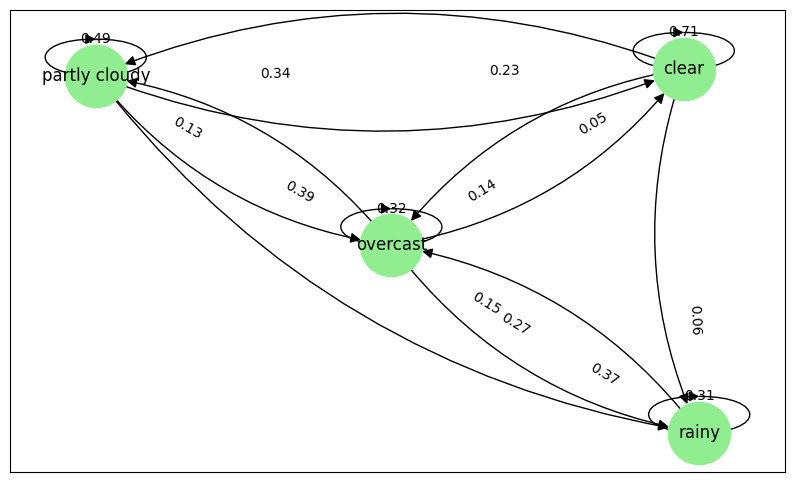

In [4]:
import networkx as nx
G = nx.MultiDiGraph()
for start_node in transition_matrix.index:
  for end_node in transition_matrix.columns:
    prob = transition_matrix.loc[start_node, end_node]
    if prob > .05:
      G.add_edge(start_node, end_node, prob, label=f"{prob:.2f}")

pos = nx.spring_layout(G, seed=12)
plt.figure(figsize=(10,6));
node_size=2000
nx.draw_networkx_nodes(G,pos, node_size=node_size, node_color='lightgreen');
nx.draw_networkx_labels(G,pos);
nx.draw_networkx_edges(G,pos,connectionstyle='arc3,rad=.2',arrowsize=15, node_size=node_size);
labels = nx.get_edge_attributes(G,'label')
nx.draw_networkx_edge_labels(G,pos,edge_labels=labels, label_pos=0.7, bbox=dict(alpha=0));

In [5]:
conditions = list(X.conditions.unique())
transition_probs = {} # Just to and from rainy/overcast
for c1 in conditions:
  for c2 in conditions:
    transition_probs[(c1,c2)] = float(transition_matrix[c2][c1])
transition_probs

{('overcast', 'overcast'): 0.3170731707317073,
 ('overcast', 'partly cloudy'): 0.1301775147928994,
 ('overcast', 'clear'): 0.05210800568450971,
 ('overcast', 'rainy'): 0.3695652173913043,
 ('partly cloudy', 'overcast'): 0.39372822299651566,
 ('partly cloudy', 'partly cloudy'): 0.4904667981591059,
 ('partly cloudy', 'clear'): 0.23117006158218853,
 ('partly cloudy', 'rainy'): 0.26521739130434785,
 ('clear', 'overcast'): 0.14111498257839722,
 ('clear', 'partly cloudy'): 0.3445101906640368,
 ('clear', 'clear'): 0.7067740407389863,
 ('clear', 'rainy'): 0.05652173913043478,
 ('rainy', 'overcast'): 0.1480836236933798,
 ('rainy', 'partly cloudy'): 0.034845496383957925,
 ('rainy', 'clear'): 0.00994789199431549,
 ('rainy', 'rainy'): 0.30869565217391304}

In [6]:
from itertools import combinations_with_replacement as cwr, permutations
combs = list(cwr(['rainy','overcast'], 3))
# combs

In [7]:
permutation_list = []
for c in combs:
  perms = list(permutations(c))
  perms = list(set(perms))
  for perm in perms:
    new_perm = ['partly cloudy'] + list(perm) + ['partly cloudy'] # surround with partly cloudy days
    permutation_list.append(new_perm)
# permutation_list

In [12]:
highest = -1
lowest = 1
highest_combo = None
lowest_combo = None
for perm in permutation_list:
  current = perm[0:-1]
  next = perm[1:]
  combo = list(zip(current,next))
  val = 1
  for c in combo:
    val *= transition_probs[c]
  if val > highest:
    highest = val
    highest_combo = perm
  if val < lowest:
    lowest = val
    lowest_combo = perm

print(1/highest, highest_combo)
print(1/lowest, lowest_combo)
# Assumption, this worst case is surrounded by a sunny or
# partly cloudy day so the battery can recover. To and from partly
# cloudy is more likely (more limiting on assumptions), so we will add
# those two factors in to adjust the new worst case. i.e. (multiply
# transitions from partly cloudy to the first rainy day and from
# the last rainy day back out to partly cloudy)

194.06556717618665 ['partly cloudy', 'overcast', 'overcast', 'overcast', 'partly cloudy']
1977.2119310270275 ['partly cloudy', 'rainy', 'overcast', 'rainy', 'partly cloudy']


In [9]:
solarenergy = X.groupby('conditions').solarenergy.mean()
solarenergy

,solarenergy
conditions,
clear,22.577546
overcast,10.780870
partly cloudy,19.057068
rainy,5.019565


In [10]:
!pip install netgraph

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.7/96.7 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 372.3/372.3 kB 12.3 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/netgraph/_utils.py:360: RuntimeWarning: invalid value encountered in divide
  v = v / np.linalg.norm(v, axis=-1)[:, None] # unit vector


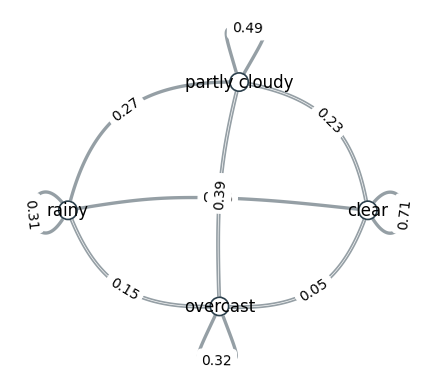

In [11]:
from netgraph import Graph
# This library handles the curvatures and label alignments out of the box
G1 = nx.DiGraph(G)
edge_labels = { (u,v): d['label'] for u,v,d in G1.edges(data=True)}

Graph(G1, node_labels=True, edge_labels=edge_labels, edge_layout='curved',
      node_label_fontdict=dict(size=12),edge_label_fontdict=dict(size=10));

# Battery Simulation
Simulate and plot the battery level over a five-day period using weather data from "irvine_dat.csv".

In [22]:
battery_capacity = 16.5  # Wh (3.3V at 5000mAh)
min_soc = 0.20             # 20% minimum state of charge
load = .924    # W 3.3V at 280mA. A worst case high-load
solar_panel_area_m2 = .025   # about 38 sq-inches (6x6)
solar_panel_efficiency = 0.20 # 20% efficiency is typical
MJ2Wh = 1000000/3600 # MegaJoules to Wh (convert provided units MJ to Wh)

print(f"Battery Capacity: {battery_capacity} Wh")
print(f"Minimum State of Charge: {min_soc*100}%")
print(f"Load: {load} W")
print(f"Solar Panel Area: {solar_panel_area_m2} m^2")
print(f"Solar Panel Efficiency: {solar_panel_efficiency*100}%")

solarenergy = X.groupby('conditions').solarenergy.mean()

solar_energy_clear = solarenergy['clear'] * solar_panel_area_m2 * solar_panel_efficiency * MJ2Wh
solar_energy_overcast = solarenergy['overcast'] * solar_panel_area_m2 * solar_panel_efficiency * MJ2Wh
solar_energy_partly_cloudy = solarenergy['partly cloudy'] * solar_panel_area_m2 * solar_panel_efficiency * MJ2Wh
solar_energy_rainy = solarenergy['rainy'] * solar_panel_area_m2 * solar_panel_efficiency * MJ2Wh

print(f"Daily Usable Solar Energy (Clear): {solar_energy_clear:.2f} Wh")
print(f"Daily Usable Solar Energy (Overcast): {solar_energy_overcast:.2f} Wh")
print(f"Daily Usable Solar Energy (Partly Cloudy): {solar_energy_partly_cloudy:.2f} Wh")
print(f"Daily Usable Solar Energy (Rainy): {solar_energy_rainy:.2f} Wh")

Battery Capacity: 16.5 Wh
Minimum State of Charge: 20.0%
Load: 0.924 W
Solar Panel Area: 0.025 m^2
Solar Panel Efficiency: 20.0%
Daily Usable Solar Energy (Clear): 31.36 Wh
Daily Usable Solar Energy (Overcast): 14.97 Wh
Daily Usable Solar Energy (Partly Cloudy): 26.47 Wh
Daily Usable Solar Energy (Rainy): 6.97 Wh


In [26]:
from math import sin, pi

# Define the weather_sequence for the 5-day period based on lowest_combo from previous analysis
# lowest_combo: ['partly cloudy', 'rainy', 'overcast', 'rainy', 'partly cloudy']
weather_sequence = ['partly cloudy', 'rainy', 'overcast', 'rainy', 'partly cloudy']
battery_managment_enabled = True # with true low battery mode at 50%

days = len(weather_sequence)
daylight_hours_start = 8
hours_sun = 10
daylight_start = 8 # eg 8 am
daylight_hours_range = range(daylight_start, daylight_start + hours_sun) # Hours from 8 to 17

battery_levels = []
current_soc = battery_capacity # Start fully charged
battery_levels.append(current_soc) # Append initial state

min_battery_level = min_soc * battery_capacity

energy_map = {
    'clear': solar_energy_clear,
    'overcast': solar_energy_overcast,
    'partly cloudy': solar_energy_partly_cloudy,
    'rainy': solar_energy_rainy
}


def adjust_load(soc):
  # if battery charge below 50%, cut load in half
  if battery_managment_enabled:
    if soc < .5 * battery_capacity:
      return load/2
  return load

def solar_charging(energy, t):
  # reimann-sum-like area under sine curve shifted and scaled
  # so half a period corresponds to the total daylight hours
  return (energy*pi/10)*sin((pi/hours_sun)*(t-daylight_hours_start))

# Loop through each of the num_simulation_days
for day in range(days):
  weather = weather_sequence[day]
  solar_energy = energy_map[weather]

  load_draw = adjust_load(current_soc) # load (adjsuted if low batt)

  # Within each day's loop, loop through 24 hours
  for hour in range(24):
    if hour in daylight_hours_range:
      charging = solar_charging(solar_energy,hour)
    else:
      charging = 0

    # Update current_soc
    current_soc += charging - load_draw
    load_draw = adjust_load(current_soc) # load (adjsuted if low batt)

    # keep battery within the operational limits
    current_soc = max(min_battery_level, min(battery_capacity, current_soc))

    battery_levels.append(current_soc) # y for plotting

print(f"Simulation complete. {len(battery_levels)} hours, ({round(len(battery_levels)/24)} days) of battery levels (Wh) recorded.")

Simulation complete. 121 hours, (5 days) of battery levels (Wh) recorded.


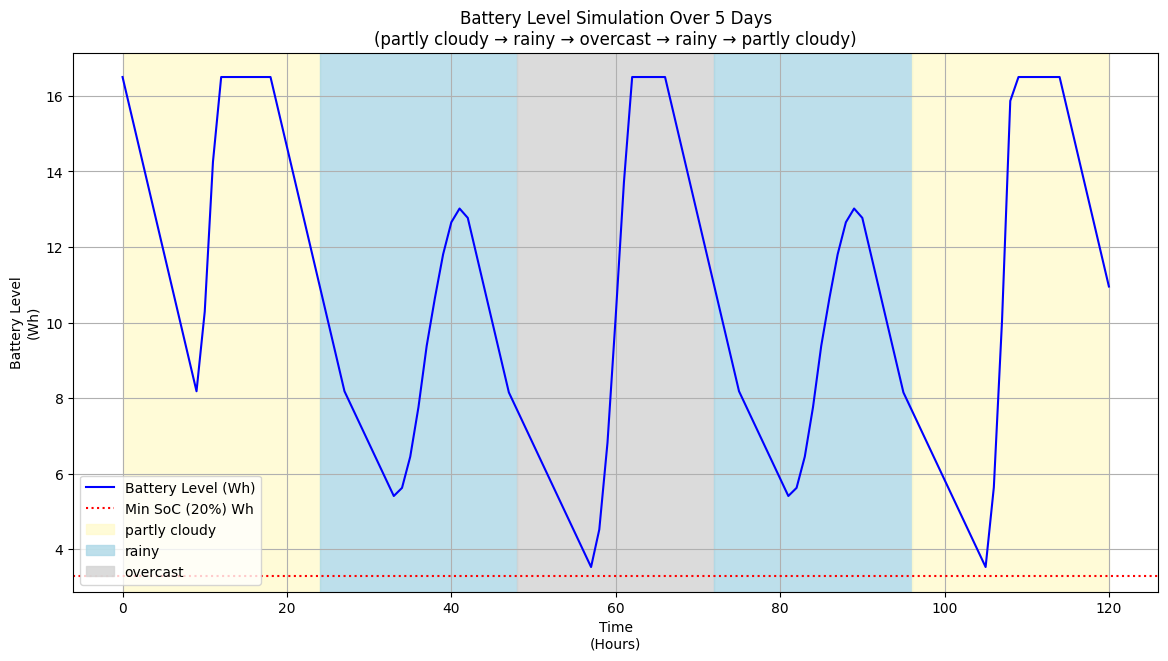

In [24]:
time_hours = range(len(battery_levels))

weather_colormap = {'clear':'cyan', 'overcast':'lightgrey', 'partly cloudy':'lemonchiffon', 'rainy':'lightblue'}

plt.figure(figsize=(14, 7))
plt.plot(time_hours, battery_levels, label='Battery Level (Wh)', color='blue')

# Add min SoC line
min_battery_level_percentage = min_soc * 100
plt.axhline(y=min_battery_level_percentage * (battery_capacity / 100), color='red', linestyle=':', label=f'Min SoC ({min_battery_level_percentage:.0f}%) Wh')

# color background based on weather
for i, weather in enumerate(weather_sequence):
  if weather not in plt.gca().get_legend_handles_labels()[1]:
    label = weather
  else:
    label = None
  plt.axvspan(i*24, (i+1)*24, color=weather_colormap[weather], alpha=0.8, label=label)

plt.title(f'Battery Level Simulation Over {len(weather_sequence)} Days\n({" → ".join(weather_sequence)})')
plt.xlabel('Time\n(Hours)')
plt.ylabel('Battery Level\n(Wh)')
plt.grid(True)
plt.legend()
plt.show()